In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interpn
import plotly.graph_objects as go
from functions import *

In [2]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

In [3]:
# ix, iy, iz = u_data['dimensions']
# xstart, ystart, zstart = u_data['origin_m']
# dx, dy, dz = u_data['resolution_m']

# #сетки координат
# x = np.arange(xstart, xstart + ix * dx, dx)
# y = np.arange(ystart, ystart + iy * dy, dy)
# z = np.arange(zstart, zstart + iz * dz, dz)
# X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# # Заданная точка
# x0, y0, z0 = 0, 0, 0  

# # Вычисление разностей координат
# delta_x = X - x0
# delta_y = Y - y0
# delta_z = Z - z0

# distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

# distance[distance == 0] = 1e-10

# # Расчет радиальной скорости
# U = u_data['data']
# V = v_data['data']
# W = w_data['data']
# radial_velocity = (U * delta_x + V * delta_y + W * delta_z) / distance



# z_slice = 3

# # print("Размерность поля радиальных скоростей:", radial_velocity.shape)


# plt.figure(figsize=(10, 7))
# plt.imshow(
#     radial_velocity[:, :, z_slice],
#     cmap='coolwarm',
#     origin='lower',
#     extent=[x.min(), x.max(), y.min(), y.max()]
# )
# plt.colorbar(label='Радиальная скорость (м/с)')
# plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')

# plt.scatter(-3900, -3900, color='red', marker='X', s=100, label='Наблюдатель') 
# plt.legend()

# plt.xlabel('X (метры)')
# plt.ylabel('Y (метры)')
# plt.show()

# # --- 3D-график ---
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# scatter = ax.scatter(
#     X[:, :, z_slice].flatten(),
#     Y[:, :, z_slice].flatten(),
#     Z[:, :, z_slice].flatten(),
#     c=radial_velocity[:, :, z_slice].flatten(),
#     cmap='coolwarm'
# )

# ax.scatter(x0, y0, z0, color='red', marker='X', s=200, label='Наблюдатель') 

# cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
# cbar.set_label('Radial Velocity (m/s)', rotation=270, labelpad=15)
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')
# plt.legend()

# plt.show()

In [4]:

def spherical_to_cartesian(azimuth_deg, elevation_deg):
    """Конвертируем углы в направляющий вектор"""
    azimuth = np.radians(azimuth_deg)
    elevation = np.radians(elevation_deg)
    x = np.cos(elevation) * np.cos(azimuth)
    y = np.cos(elevation) * np.sin(azimuth)
    z = np.sin(elevation)
    return np.array([x, y, z])

def line_parametric(t, origin, direction):
    """Параметрическое уравнение прямой"""
    return origin + direction * t

def find_intersection(matrix_shape, origin, direction):
    """Находим точки пересечения прямой с границами матрицы"""
    def get_t(axis, boundary):
        return (boundary - origin[axis]) / direction[axis] if direction[axis] != 0 else np.nan
    
    min_bounds = np.array([0, 0, 0])
    max_bounds = np.array(matrix_shape) - 1e-6  #  краевые эффекты
    
    t_enter = []
    t_exit = []
    
    for i in range(3):
        t1 = get_t(i, min_bounds[i])
        t2 = get_t(i, max_bounds[i])
        t_enter.append(min(t1, t2))
        t_exit.append(max(t1, t2))
    
    # Исправленный блок 
    valid_t_enter = [t for t in t_enter if not np.isnan(t)]
    valid_t_exit = [t for t in t_exit if not np.isnan(t)]
    
    t_start = max([0] + valid_t_enter) if valid_t_enter else np.nan 
    t_end = min(valid_t_exit) if valid_t_exit else np.nan    
    
    if np.isnan(t_start) or np.isnan(t_end) or t_start > t_end:
        return np.nan, np.nan
    
    
    # t_start = max(0, *[t for t in t_enter if not np.isnan(t)])
    # t_end = min(*[t for t in t_exit if not np.isnan(t)])
    
    return t_start, t_end

def trilinear_interpolation(matrix, x, y, z):
    """Трилинейная интерполяция"""
    x0, y0, z0 = np.floor([x, y, z]).astype(int)
    x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
    
    # обработка выхода за границы
    x0, x1 = np.clip([x0, x1], 0, matrix.shape[0]-1)
    y0, y1 = np.clip([y0, y1], 0, matrix.shape[1]-1)
    z0, z1 = np.clip([z0, z1], 0, matrix.shape[2]-1)
    
    xd = (x - x0) / (x1 - x0) if (x1 - x0) != 0 else 0
    yd = (y - y0) / (y1 - y0) if (y1 - y0) != 0 else 0
    zd = (z - z0) / (z1 - z0) if (z1 - z0) != 0 else 0

    c00 = matrix[x0, y0, z0] * (1 - xd) + matrix[x1, y0, z0] * xd
    c01 = matrix[x0, y0, z1] * (1 - xd) + matrix[x1, y0, z1] * xd
    c10 = matrix[x0, y1, z0] * (1 - xd) + matrix[x1, y1, z0] * xd
    c11 = matrix[x0, y1, z1] * (1 - xd) + matrix[x1, y1, z1] * xd

    c0 = c00 * (1 - yd) + c10 * yd
    c1 = c01 * (1 - yd) + c11 * yd

    return c0 * (1 - zd) + c1 * zd


In [5]:
def plot_line_results(V_radial, z0, x, y, z,  points, values, distance, observer_position):
    """
    Визуализация результатов: радиальная скорость и профиль скорости.
    
    Args:
        V_radial (np.ndarray): 3D массив радиальных скоростей.
        z0 (int): Величина в метрах среза  Z.
        x (np.ndarray): Координаты по оси X.
        y (np.ndarray): Координаты по оси Y.
        points (np.ndarray): Точки на линии.
        values (list): Значения радиальной скорости в точках.
        distance (np.ndarray): Расстояния между точками.
        observer_position (tuple): Позиция наблюдателя (x0, y0).
    """
    import matplotlib.pyplot as plt
    z_slice = np.argmin(np.abs(z - z0))  # Индекс слоя z

    # Срез радиальной скорости
    radial_slice = V_radial[:, :, z_slice]

    plt.figure(figsize=(14, 6))

    # Подграфик 1: Вид сверху
    plt.subplot(1, 2, 1)
    plt.imshow(
        radial_slice.T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Радиальная скорость (м/с)')

    # Точки линии
    plt.scatter(
        points[:, 0], points[:, 1],
        c=values, cmap='coolwarm', s=50, edgecolor='w',
        label='Точки линии'
    )
    plt.plot(points[:, 0], points[:, 1], color='blue', linestyle='-', linewidth=2, label='Линия')
    
    # Наблюдатель
    plt.scatter(
        observer_position[0]+0, observer_position[1]+0,
        color='red', marker='X', s=100, label='Наблюдатель'
    )

    # Подписи значений у точек
    for i in range(len(points)):
        plt.text(
            points[i, 0], points[i, 1],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.title(f'Вид сверху (z={z0} м)')
    plt.legend()
    plt.grid(True)

    # Подграфик 2: Профиль скорости
    plt.subplot(1, 2, 2)
    plt.plot(distance, values, marker='o', linestyle='-', color='b')
    plt.xlabel('Расстояние вдоль линии (м)')
    plt.ylabel('Радиальная скорость (м/с)')
    plt.title('Профиль радиальной скорости')
    plt.grid(True)

    # Подписи значений у профиля
    for i in range(len(distance)):
        plt.text(
            distance[i], values[i],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.tight_layout()
    plt.show()

[[-4000.             0.            80.27368991]
 [-3794.87179615     0.           100.85668719]
 [-3589.74359231     0.           121.43968448]
 [-3384.61538846     0.           142.02268176]
 [-3179.48718462     0.           162.60567904]
 [-2974.35898077     0.           183.18867633]
 [-2769.23077692     0.           203.77167361]
 [-2564.10257308     0.           224.35467089]
 [-2358.97436923     0.           244.93766818]
 [-2153.84616538     0.           265.52066546]
 [-1948.71796154     0.           286.10366275]
 [-1743.58975769     0.           306.68666003]
 [-1538.46155385     0.           327.26965731]
 [-1333.33335        0.           347.8526546 ]
 [-1128.20514615     0.           368.43565188]
 [ -923.07694231     0.           389.01864916]
 [ -717.94873846     0.           409.60164645]
 [ -512.82053462     0.           430.18464373]
 [ -307.69233077     0.           450.76764102]
 [ -102.56412692     0.           471.3506383 ]
 [  102.56407692     0.           491.93

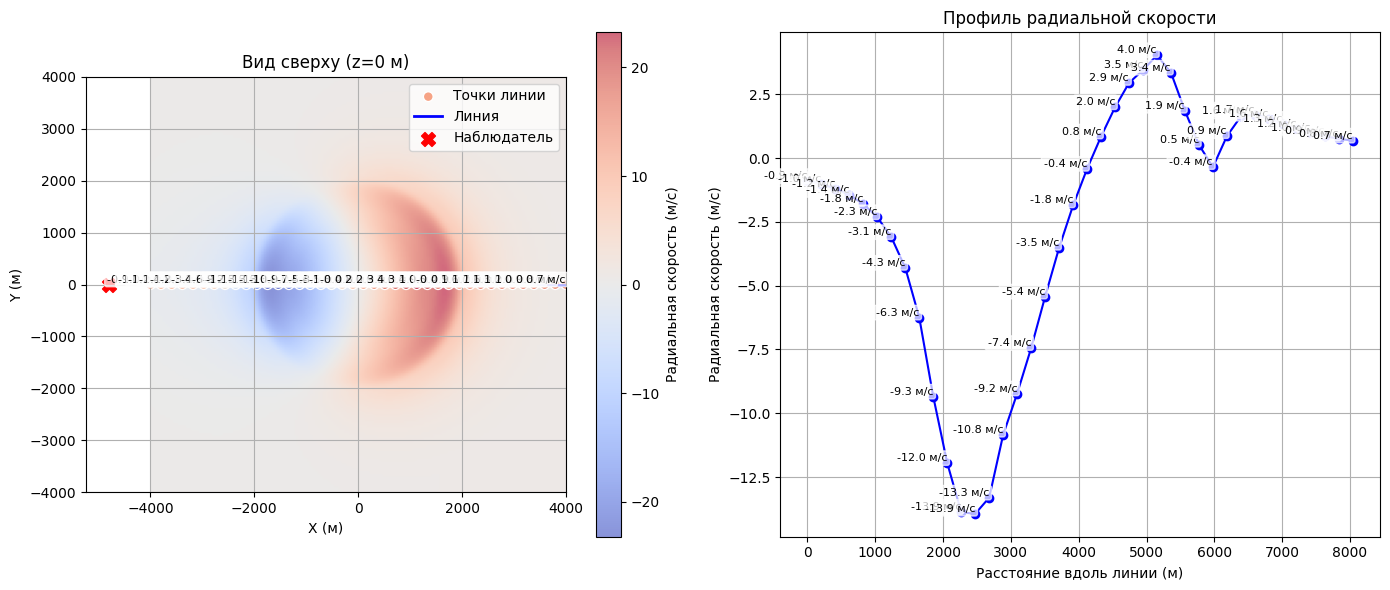

In [39]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  -4800, 0, 0# Точка наблюдателя
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = 5.73  # Вертикальный угол
num_points = 40    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


<h1><center>Figure B-65: FLWS Scenario 1: Data Set/Time #111, Aligned for Takeoff on Track 90</center></h1>

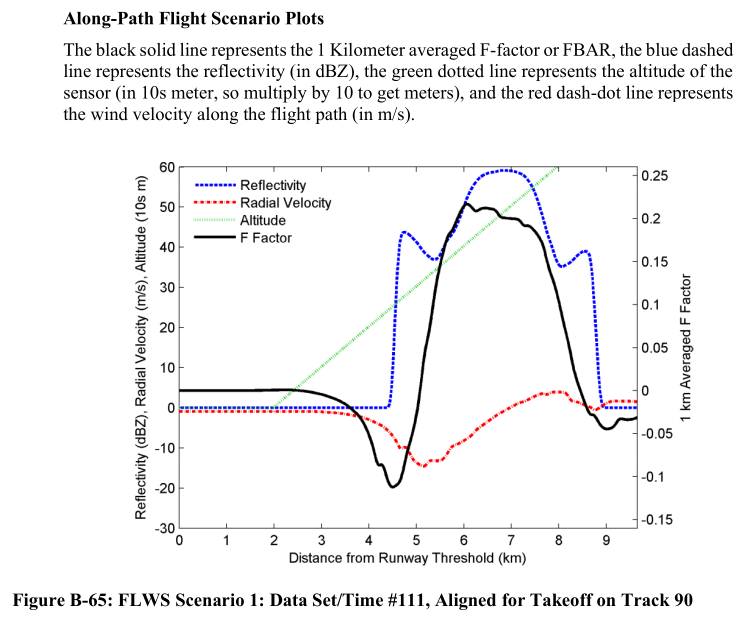


[[-4.00000000e+03  0.00000000e+00  2.24986293e+02]
 [-3.97842716e+03  0.00000000e+00  2.23855709e+02]
 [-3.95685433e+03  0.00000000e+00  2.22725124e+02]
 [-3.93528149e+03  0.00000000e+00  2.21594540e+02]
 [-3.91370866e+03  0.00000000e+00  2.20463956e+02]
 [-3.89213582e+03  0.00000000e+00  2.19333371e+02]
 [-3.87056299e+03  0.00000000e+00  2.18202787e+02]
 [-3.84899015e+03  0.00000000e+00  2.17072203e+02]
 [-3.82741732e+03  0.00000000e+00  2.15941618e+02]
 [-3.80584448e+03  0.00000000e+00  2.14811034e+02]
 [-3.78427165e+03  0.00000000e+00  2.13680449e+02]
 [-3.76269881e+03  0.00000000e+00  2.12549865e+02]
 [-3.74112598e+03  0.00000000e+00  2.11419281e+02]
 [-3.71955314e+03  0.00000000e+00  2.10288696e+02]
 [-3.69798031e+03  0.00000000e+00  2.09158112e+02]
 [-3.67640747e+03  0.00000000e+00  2.08027527e+02]
 [-3.65483464e+03  0.00000000e+00  2.06896943e+02]
 [-3.63326180e+03  0.00000000e+00  2.05766359e+02]
 [-3.61168897e+03  0.00000000e+00  2.04635774e+02]
 [-3.59011613e+03  0.00000000e+

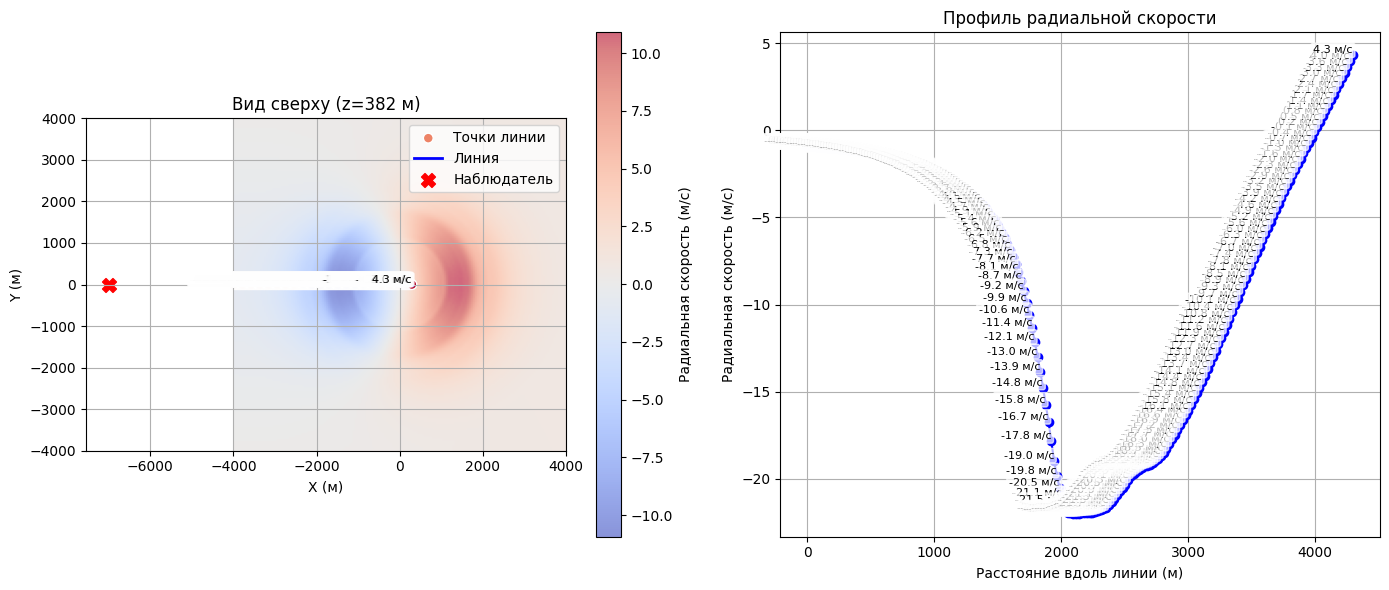

In [57]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
# x0, y0, z0 =  -900, 0, 63 # Точка наблюдателя
x0, y0, z0 =  -6996, 0, 382 # Точка наблюдателя 
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 200    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


# Шаги изменения
dx = -85.86511509
dy = 4.5

first_x = points[0, 0]
first_y = points[0, 1]
first_z = points[0, 2]

new_data = []
for i in range(1, 100):
    new_x = first_x + i * dx
    new_y = first_y 
    new_z = first_z + i * dy
    new_data.append([new_x, new_y, new_z])

new_data = np.array(new_data)
# print(new_data)


<h1><center>Figure B-66: FLWS Scenario 2: Data Set/Time #111, Straight-In Approach on Track 90</center></h1>

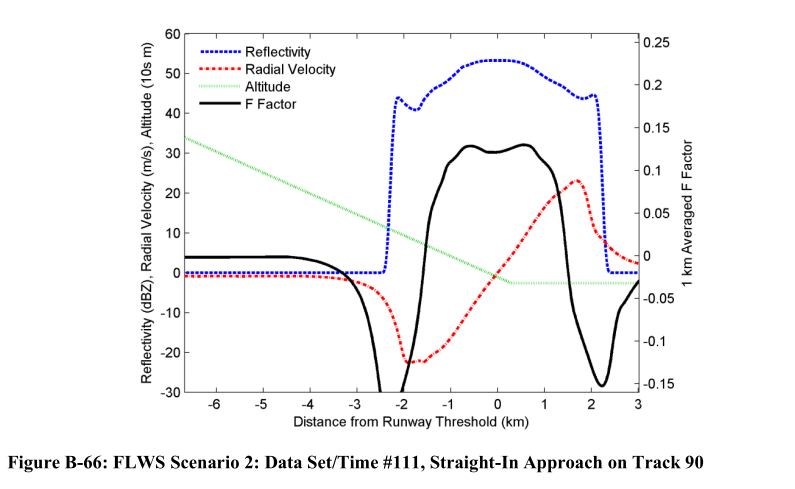


[[-1800.         -8880.           370.70288558]
 [-1800.         -8507.71408262   351.19220739]
 [-1800.         -8135.42816524   331.6815292 ]
 [-1800.         -7763.14224786   312.17085101]
 [-1800.         -7390.85633048   292.66017282]
 [-1800.         -7018.5704131    273.14949464]
 [-1800.         -6646.28449571   253.63881645]
 [-1800.         -6273.99857833   234.12813826]
 [-1800.         -5901.71266095   214.61746007]
 [-1800.         -5529.42674357   195.10678188]
 [-1800.         -5157.14082619   175.59610369]
 [-1800.         -4784.85490881   156.08542551]
 [-1800.         -4412.56899143   136.57474732]
 [-1800.         -4040.28307405   117.06406913]
 [-1800.         -3667.99715667    97.55339094]
 [-1800.         -3295.71123929    78.04271275]
 [-1800.         -2923.42532191    58.53203456]
 [-1800.         -2551.13940453    39.02135638]
 [-1800.         -2178.85348714    19.51067819]
 [-1800.         -1806.56756976     0.        ]]


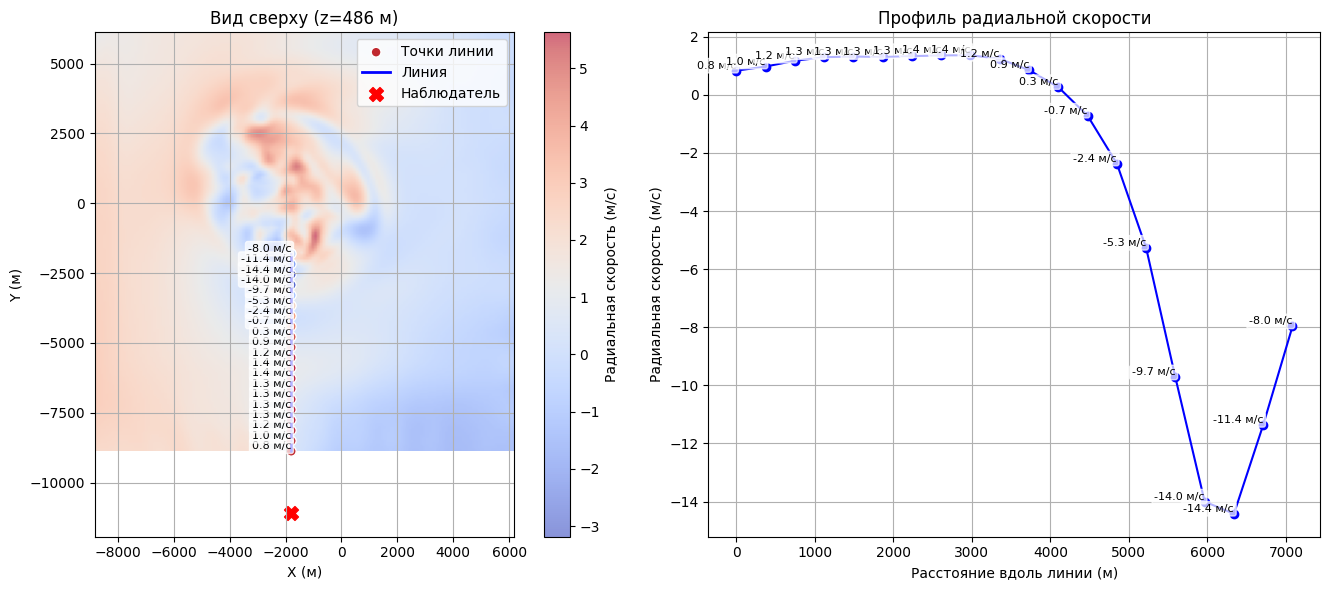

In [43]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_w.faa")


origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
# x0, y0, z0 =  -1800, -1900, 63# Точка наблюдателя
x0, y0, z0 =  -1800, -11080, 486#  [ -8980.17667522      0.            485.98629327]

# Параметры линии
azimuth_deg = 90 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


<h1><center>Figure B-67: FLWS Scenario 3: Data Set/Time #237, Straight-In Approach on Track 180</center></h1>

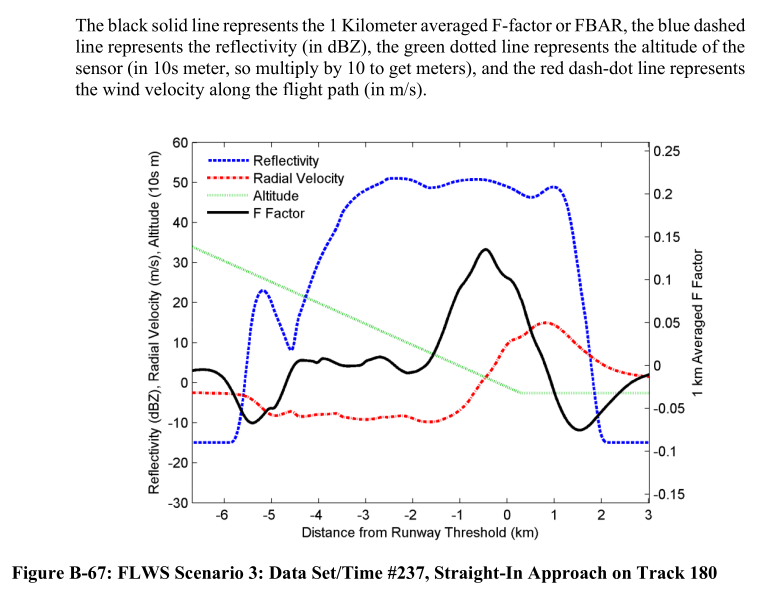

[[-8834.         -1100.           377.88965862]
 [-8454.49661953 -1100.           358.00072922]
 [-8074.99323906 -1100.           338.11179982]
 [-7695.48985858 -1100.           318.22287042]
 [-7315.98647811 -1100.           298.33394101]
 [-6936.48309764 -1100.           278.44501161]
 [-6556.97971717 -1100.           258.55608221]
 [-6177.47633669 -1100.           238.66715281]
 [-5797.97295622 -1100.           218.77822341]
 [-5418.46957575 -1100.           198.88929401]
 [-5038.96619528 -1100.           179.00036461]
 [-4659.46281481 -1100.           159.11143521]
 [-4279.95943433 -1100.           139.22250581]
 [-3900.45605386 -1100.           119.33357641]
 [-3520.95267339 -1100.            99.444647  ]
 [-3141.44929292 -1100.            79.5557176 ]
 [-2761.94591244 -1100.            59.6667882 ]
 [-2382.44253197 -1100.            39.7778588 ]
 [-2002.9391515  -1100.            19.8889294 ]
 [-1623.43577103 -1100.             0.        ]]


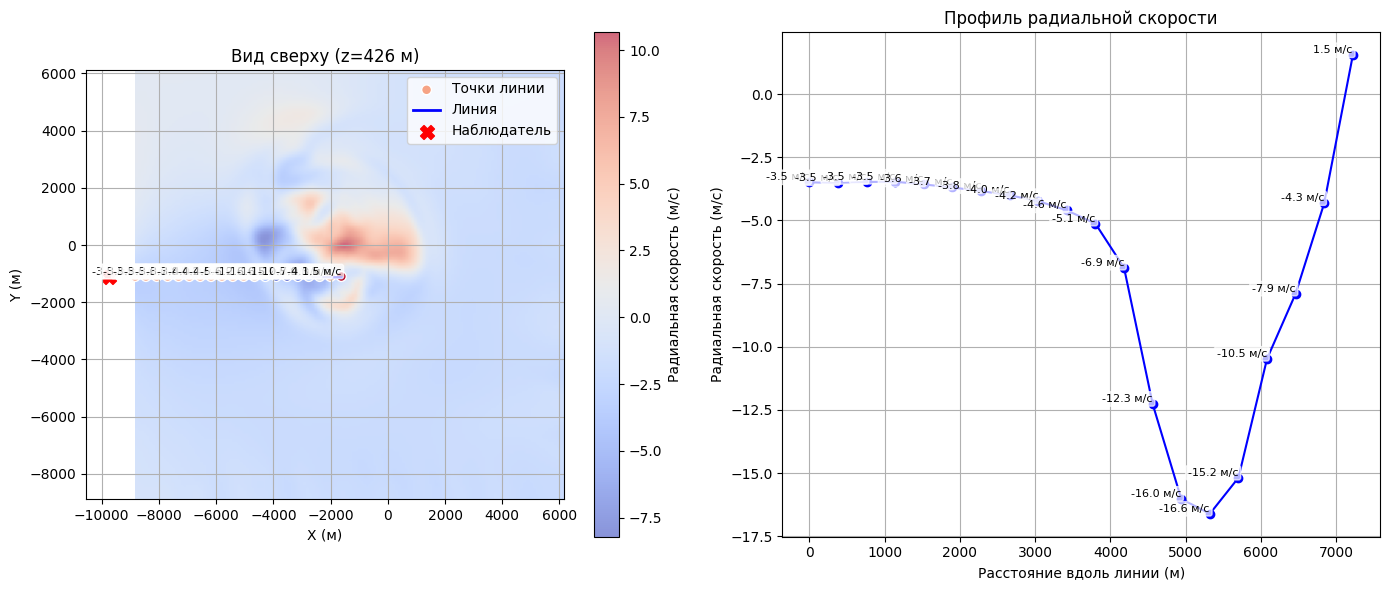

In [54]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_w.faa")


origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  -9752, -1100, 426# Точка наблюдателя
 # [ -9752.96271103      0.            526.48629327]
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))


<h1><center>Figure B-68: FLWS Scenario 4: Data Set/Time #237, Straight-In Approach on Track 90, Below</center></h1>

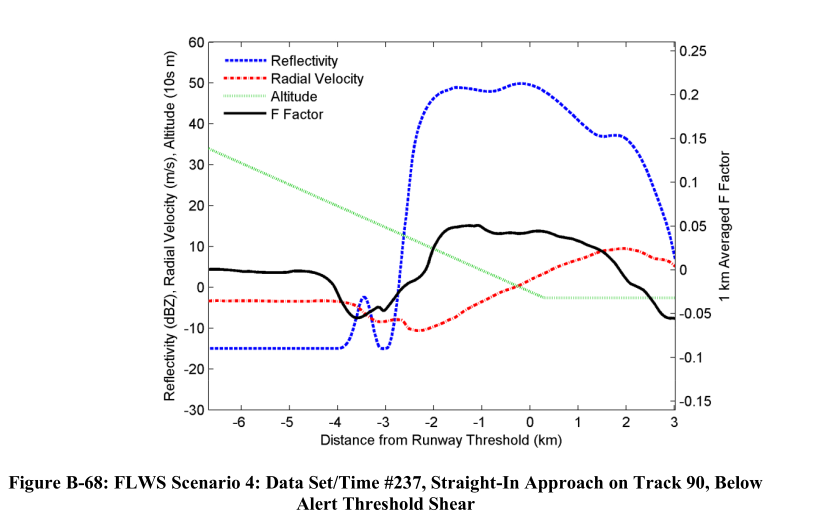

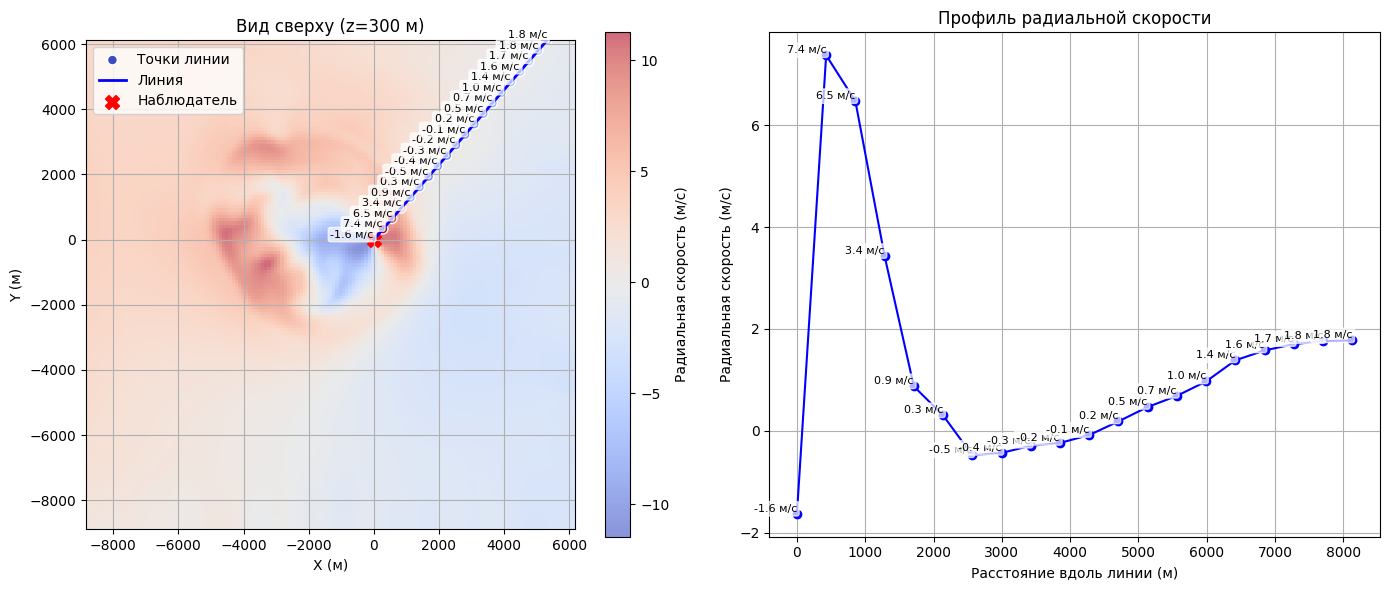

In [10]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  0, 0, 300 # Точка наблюдателя
# Параметры линии
azimuth_deg = 49    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 5. Линия с измененным вертикальным углом на +4 и горизонтальный угол на +4</center></h1>

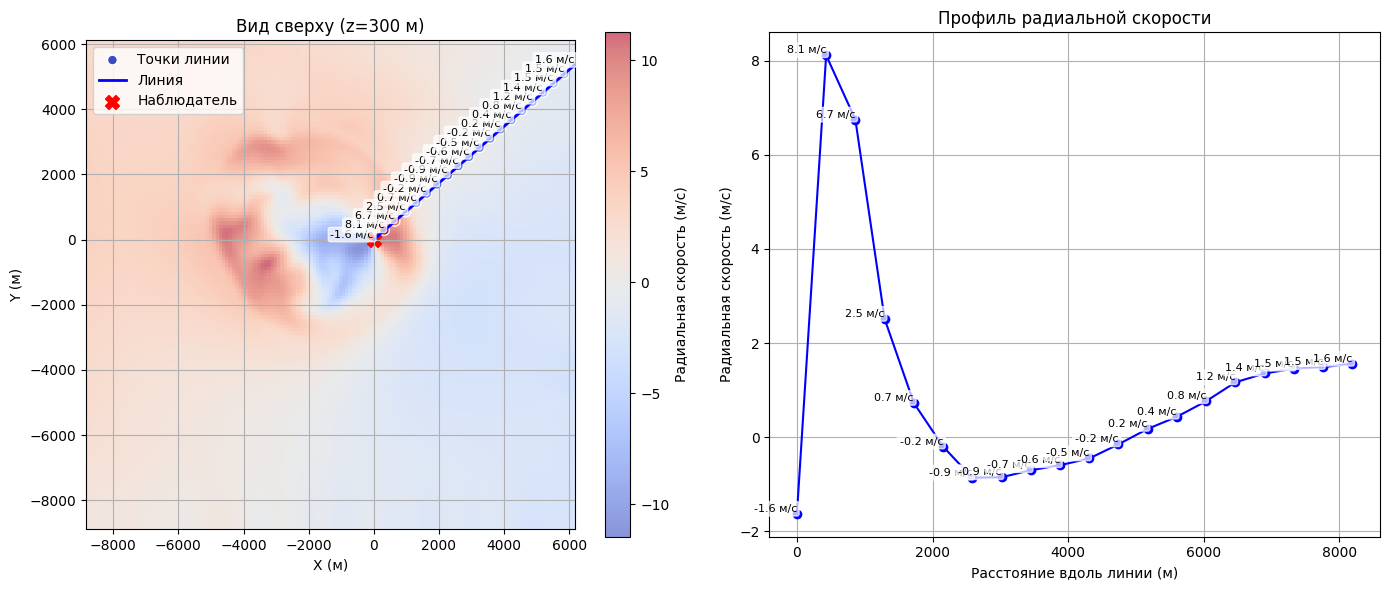

In [11]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  0, 0, 300 # Точка наблюдателя
# Параметры линии
azimuth_deg = 41    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z0, x, y, z, points, values, distance, observer_position=(x0, y0))

<h1><center>График — 6. Линия с измененным вертикальным углом на +4 и горизонтальный угол на -4</center></h1>